# Global Explainability of Tabular Models
### Feature Importance, Partial Dependence Plots (PDP/ICE) 
**Dataset:** UCI *Adult / Census Income* (`https://archive.ics.uci.edu/dataset/2/adult`)

---

## 1. Why "global" explainability?

Explainability methods split into two families:

| | Question answered | Typical output | Examples |
|---|---|---|---|
| **Local** | *Why did the model predict **this** for **this row**?* | one number per feature, per row | SHAP waterfall, LIME |
| **Global** | *What has the model learned **overall**?* | one number/curve per feature | permutation importance, PDP, mean\|SHAP\| |

This notebook builds one model and then interrogates it with four complementary **global** tools:


1. **Permutation importance** — model-agnostic, measures *how much performance depends on a feature*.
2. **Partial Dependence & ICE** — shows the *shape and direction* of a feature's effect, not just its size.


A key theme: *importance* (how much a feature matters) and *effect* (which way it pushes the prediction)
are different questions. Ranking plots answer the first; PDP and SHAP beeswarm answer the second.

## 2. Setup

Uncomment the install line the first time you run this notebook.

In [1]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: shap in c:\users\vineetha n\appdata\roaming\python\python312\site-packages (0.52.0)
  Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Rolling back uninstall of numpy
  Moving to c:\users\vineetha n\appdata\roaming\python\python312\scripts\f2py.exe
   from C:\Users\vineetha n\AppData\Local\Temp\pip-uninstall-e70jdxel\f2py.exe
  Moving to c:\users\vineetha n\appdata\roaming\python\python312\site-packages\numpy-1.26.4-cp312-cp312-win_amd64.whl
   from C:\Users\vineetha n\AppData\Local\Temp\pip-uninstall-jxwcassa\numpy-1.26.4-cp312-cp312-win_amd64.whl
  Moving to c:\users\vineetha n\appdata\roami

ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'c:\\Python312\\Scripts\\f2py.exe' -> 'c:\\Python312\\Scripts\\f2py.exe.deleteme'


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)

c:\Python312\python.exe


In [3]:
import sys
!{sys.executable} -m pip install shap

ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'c:\\Python312\\Scripts\\f2py.exe' -> 'c:\\Python312\\Scripts\\f2py.exe.deleteme'


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Rolling back uninstall of numpy
  Moving to c:\users\vineetha n\appdata\roaming\python\python312\scripts\f2py.exe
   from C:\Users\vineetha n\AppData\Local\Temp\pip-uninstall-mdct4c9l\f2py.exe
  Moving to c:\users\vineetha n\appdata\roaming\python\python312\site-packages\numpy-1.26.4-cp312-cp312-win_amd64.whl
   from C:\Users\vineetha n\AppData\Local\Temp\pip-uninstall-6sxidl_7\numpy-1.26.4-cp312-cp312-win_amd64.whl
  Moving to c:\users\vineetha n\appdata\roaming\python\python312\site-packages\numpy-1.26.4.dist-info\
   from C:\Users\vineetha n\AppData\Roaming\Python\Python312\site-packages\~umpy-1.26.4.dist-info
  Moving to c:\users\vi

In [4]:
import shap
print("SHAP version:", shap.__version__)

c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [5]:
import sys
!{sys.executable} -m pip show shap

Name: shap
Version: 0.52.0
Summary: A unified approach to explain the output of any machine learning model.
Home-page: 
Author: 
Author-email: Scott Lundberg <slund1@cs.washington.edu>
License: MIT License
Location: C:\Users\vineetha n\AppData\Roaming\Python\Python312\site-packages
Requires: cloudpickle, llvmlite, numba, numpy, packaging, pandas, scikit-learn, scipy, slicer, tqdm
Required-by: 


In [6]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
import shap

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})
pd.set_option("display.width", 120)

# safe subsample: never asks for more rows than exist
def sample_df(df, n, seed=RANDOM_STATE):
    return df.sample(min(n, len(df)), random_state=seed)

print("pandas", pd.__version__, "| shap", shap.__version__)

pandas 2.3.2 | shap 0.52.0


## 3. Load the UCI Adult dataset

**Task:** predict whether a person's income exceeds \$50K/year from 14 census attributes
(48,842 rows, mixed numeric + categorical, missing values encoded as `?`).

The loader below tries three sources in order, so it works whichever packages/mirrors are available:

1. `ucimlrepo` (the official UCI python client),
2. the raw UCI CSV files,
3. OpenML via `sklearn.datasets.fetch_openml`.

In [8]:
import socket

try:
    print(socket.gethostbyname("archive.ics.uci.edu"))
    print("Internet/DNS is working")
except Exception as e:
    print("DNS/Internet problem:", e)

128.195.10.252
Internet/DNS is working


In [11]:
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=2)

print("UCI Adult dataset downloaded successfully!")
print("Features:", ds.data.features.shape)
print("Target:", ds.data.targets.shape)

UCI Adult dataset downloaded successfully!
Features: (48842, 14)
Target: (48842, 1)


In [10]:
%pip install ucimlrepo


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
RAW_COLS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
            "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
            "hours-per-week", "native-country", "income"]

def _tidy(df):
    """Normalise column names, strip whitespace, turn '?' into NaN, binarise target."""
    df = df.copy()
    df.columns = [str(c).strip().lower().replace("-", "_").replace(".", "_")
                  for c in df.columns]
    # locate the target column whatever it is called
    tgt = next(c for c in ["income", "class", "target", "income_50k"] if c in df.columns)
    df = df.rename(columns={tgt: "income"})
    for c in df.select_dtypes(include=["object", "category", "string"]).columns:
        df[c] = df[c].astype(str).str.strip().replace({"?": np.nan, "nan": np.nan})
    # '>50K' and '>50K.' (the test split adds a period) both mean the positive class
    df["income"] = (df["income"].str.rstrip(".").str.strip() == ">50K").astype(int)
    return df

def load_adult():
    # --- 1) official UCI client -------------------------------------------
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=2)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        print("Source: ucimlrepo (UCI id=2)")
        return _tidy(df)
    except Exception as e:
        print("ucimlrepo unavailable ->", type(e).__name__)

    # --- 2) raw CSVs from the UCI machine-learning-databases mirror --------
    try:
        base = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"
        tr = pd.read_csv(base + "adult.data", names=RAW_COLS, skipinitialspace=True)
        te = pd.read_csv(base + "adult.test", names=RAW_COLS, skipinitialspace=True,
                         skiprows=1)
        print("Source: raw UCI CSV files")
        return _tidy(pd.concat([tr, te], ignore_index=True))
    except Exception as e:
        print("raw UCI download failed ->", type(e).__name__)

    # --- 3) OpenML mirror --------------------------------------------------
    from sklearn.datasets import fetch_openml
    d = fetch_openml("adult", version=2, as_frame=True)
    print("Source: OpenML mirror")
    return _tidy(pd.concat([d.data, d.target.rename("income")], axis=1))

raw = load_adult()
print(raw.shape)
raw.head()

Source: ucimlrepo (UCI id=2)
(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


### 3.1 Light cleaning

Two columns are dropped for principled reasons — this matters for explainability, not just accuracy:

* **`fnlwgt`** is a census *sampling weight*. It is not a property of the person, so any importance
  the model assigns to it is noise we would have to explain away later.
* **`education`** is a perfect string duplicate of the ordinal **`education_num`**. Leaving both in
  would **split the credit** between two copies of the same information and make *every*
  importance measure understate education. Redundant/correlated features are the single most common
  cause of confusing explainability results.

In [13]:
df = raw.drop(columns=[c for c in ["fnlwgt", "education"] if c in raw.columns])

TARGET = "income"
y = df[TARGET]
X = df.drop(columns=[TARGET])

NUM_FEATURES = X.select_dtypes(include=np.number).columns.tolist()
CAT_FEATURES = [c for c in X.columns if c not in NUM_FEATURES]

# PDP needs floats: integer grids get silently rounded (and error out in sklearn >= 1.9)
X[NUM_FEATURES] = X[NUM_FEATURES].astype(float)

# Missingness becomes its own level. Two reasons, both about explainability:
#   (a) mixing NaN with strings in a categorical column breaks PDP's grid construction;
#   (b) in Adult, a missing workclass/occupation is itself predictive, so imputing it
#       away would silently delete a signal the explanations should surface.
X[CAT_FEATURES] = X[CAT_FEATURES].fillna("Missing")

print(f"rows={len(X):,}   positives={y.mean():.1%}")
print("numeric    :", NUM_FEATURES)
print("categorical:", CAT_FEATURES)
print("\nmissing values per column (after encoding NaN as a 'Missing' level):")
print(X.isna().sum().loc[lambda s: s > 0].to_string() or "  none")
X.head()

rows=48,842   positives=23.9%
numeric    : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

missing values per column (after encoding NaN as a 'Missing' level):
Series([], )


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


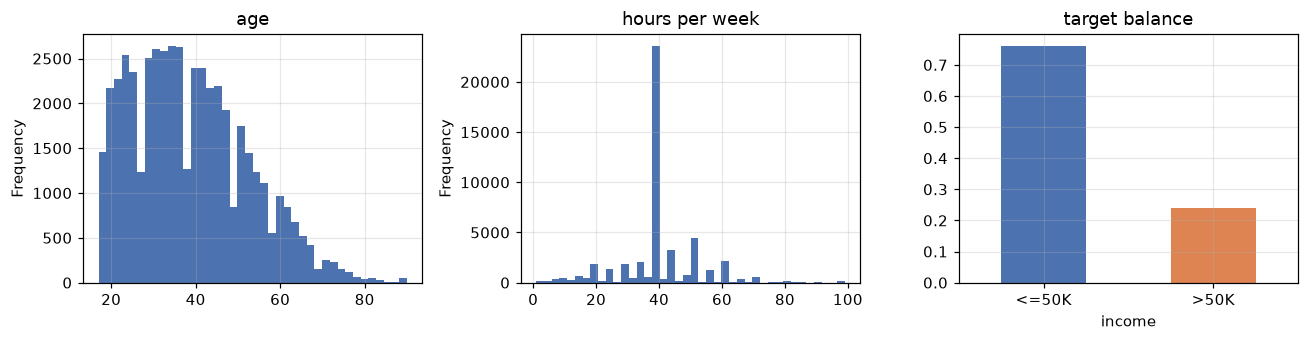

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
X["age"].plot.hist(bins=40, ax=axes[0], title="age", color="#4C72B0")
X["hours_per_week"].plot.hist(bins=40, ax=axes[1], title="hours per week", color="#4C72B0")
y.value_counts(normalize=True).rename({0: "<=50K", 1: ">50K"}).plot.bar(
    ax=axes[2], title="target balance", color=["#4C72B0", "#DD8452"], rot=0)
plt.tight_layout(); plt.show()

## 4. Preprocessing + model

Everything lives inside a single `Pipeline`. This is not cosmetic — it is what makes the rest of the
notebook correct:

* `permutation_importance` and `PartialDependenceDisplay` are handed the **pipeline**, so they
  perturb the *original, human-readable* columns (`occupation`, not `occupation_Sales`) and the
  encoding is re-applied on the fly.
* SHAP's `TreeExplainer` instead needs the **fitted tree model** and the **encoded matrix**, so we
  extract those separately in §8 and map the results back afterwards.

`min_samples_leaf=20` keeps the forest small enough that exact TreeSHAP runs in seconds rather than
minutes, at essentially no cost in accuracy.

In [15]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                              min_frequency=30), CAT_FEATURES),
    ],
    verbose_feature_names_out=True,
)

model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=20, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE,
)

pipe = Pipeline([("prep", preprocess), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, proba):.4f}\n")
print(classification_report(y_test, pred, target_names=["<=50K", ">50K"]))

accuracy : 0.8632
ROC AUC  : 0.9140

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      9289
        >50K       0.80      0.57      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.84      0.76      0.79     12211
weighted avg       0.86      0.86      0.85     12211



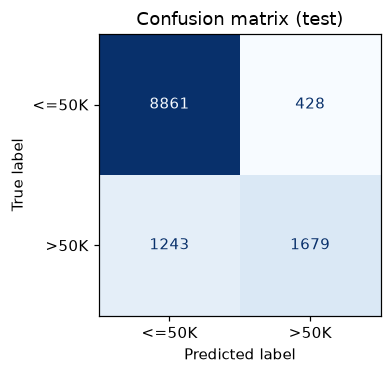

In [16]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["<=50K", ">50K"], cmap="Blues",
    colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.show()

## 6. Method 1 — Permutation importance

**Idea:** shuffle one column, breaking its relationship with the target while preserving its
marginal distribution, and measure how much a *scoring metric* degrades.

$$\text{PFI}_j \;=\; s(f, X, y) \;-\; \frac{1}{K}\sum_{k=1}^{K} s\!\left(f, X^{(k)}_{\pi_j}, y\right)$$

**Advantages:** model-agnostic; expressed in units of the metric you actually care about; computed
on **held-out** data, so it measures *generalising* signal.

**Caveats:**
* With **correlated features**, permuting one creates impossible rows (`age=20`, `marital_status=Widowed`)
  and the model is evaluated off-distribution.
* Correlated features **share credit**: two duplicate columns can each score ~0 because the model
  falls back on the other. Low permutation importance means *"the model does not need this column"*,
  **not** *"this variable is irrelevant"*.

We score with **ROC AUC** rather than accuracy — on a 24%-positive target, accuracy is too blunt to
register the degradation.

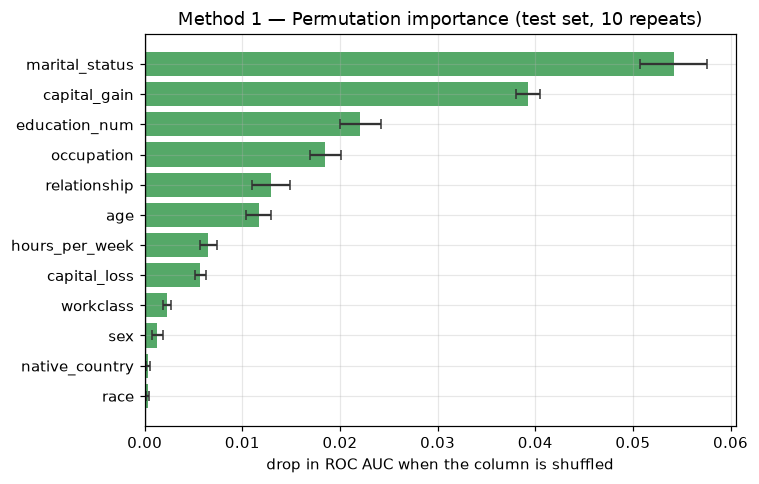

,mean,std
marital_status,0.0542,0.0034
capital_gain,0.0392,0.0012
education_num,0.0221,0.0021
occupation,0.0185,0.0016
relationship,0.0129,0.0019
age,0.0117,0.0013
hours_per_week,0.0065,0.0008
capital_loss,0.0057,0.0006
workclass,0.0023,0.0004
sex,0.0013,0.0005


In [17]:
# a 6,000-row subsample keeps runtime ~1 min without changing the ranking materially
sub = rng.choice(len(X_test), size=min(6000, len(X_test)), replace=False)
X_pi, y_pi = X_test.iloc[sub], y_test.iloc[sub]

pfi = permutation_importance(
    pipe, X_pi, y_pi, scoring="roc_auc",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

pfi_df = (pd.DataFrame({"mean": pfi.importances_mean, "std": pfi.importances_std},
                       index=X_pi.columns)
            .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(pfi_df.index[::-1], pfi_df["mean"][::-1],
        xerr=pfi_df["std"][::-1], color="#55A868", ecolor="#333", capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("drop in ROC AUC when the column is shuffled")
ax.set_title("Method 1 — Permutation importance (test set, 10 repeats)")
plt.tight_layout(); plt.show()

pfi_df.round(4)

**Reading the plot:** features whose error bar crosses zero are indistinguishable from noise for this
model. A *negative* mean is not a paradox — it means shuffling the column slightly *helped*, which is
what you expect from a variable the model uses only to fit noise.

### 6.1 Train vs test permutation importance — a free overfitting diagnostic

Running the same procedure on the training set and comparing is one of the most useful diagnostics in
this notebook: features that are important **only** on train are features the model has memorised.

## sub_tr = rng.choice(len(X_train), size=min(6000, len(X_train)), replace=False)
pfi_train = permutation_importance(
    pipe, X_train.iloc[sub_tr], y_train.iloc[sub_tr], scoring="roc_auc",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

cmp = pd.DataFrame({"train": pfi_train.importances_mean,
                    "test": pfi.importances_mean},
                   index=X_train.columns).sort_values("test", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cmp.iloc[::-1].plot.barh(ax=ax, color=["#C44E52", "#55A868"], width=.8)
ax.set_xlabel("drop in ROC AUC"); ax.axvline(0, color="k", lw=.8)
ax.set_title("Permutation importance: train vs test")
plt.tight_layout(); plt.show()

cmp.assign(gap=lambda d: d["train"] - d["test"]).round(4)

## 2. Method  — Partial Dependence & ICE

Importance rankings tell you *how much* a feature matters. They say nothing about **direction** or
**shape**: is the effect linear? monotone? does it saturate?

The partial dependence of the model $f$ on feature $S$ marginalises over all the other features $C$
using their **empirical** distribution:

$$\hat f_S(x_S) \;=\; \frac{1}{n}\sum_{i=1}^{n} f\!\left(x_S,\; x^{(i)}_C\right)$$

In words: force the whole dataset to take one value of `age`, average the predictions, repeat across
a grid. The result is the model's average response curve.

**The two caveats that matter:**

1. **Extrapolation.** The formula evaluates every combination $(x_S, x^{(i)}_C)$, including ones that
   never occur — 80-year-olds with 60-hour weeks and 16 years of education. Where a feature is
   correlated with others, part of the PDP is drawn from regions with no data.
2. **Averaging hides heterogeneity.** A flat PDP can mean "no effect" *or* "strongly positive for half
   the population, strongly negative for the other half". **ICE** curves (one line per individual,
   next section) are what distinguish these two cases.

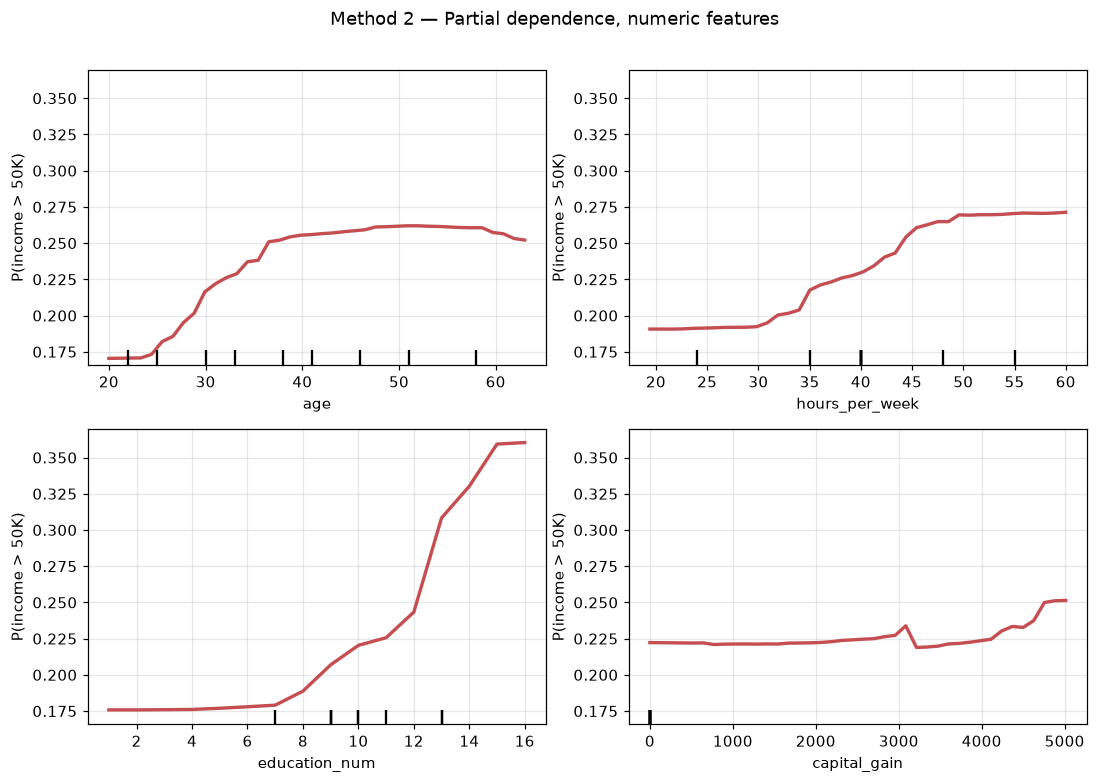

In [18]:
pdp_num = ["age", "hours_per_week", "education_num", "capital_gain"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 4000),
    features=pdp_num, kind="average", grid_resolution=40,
    ax=axes.ravel(), line_kw={"color": "#C44E52", "lw": 2.2},
    random_state=RANDOM_STATE)
for a in axes.ravel():
    a.set_ylabel("P(income > 50K)")
fig.suptitle("Method 2 — Partial dependence, numeric features", y=1.01)
plt.tight_layout(); plt.show()

The **rug marks** along the x-axis show the deciles of the data. Where they are sparse (the far right
of `capital_gain`), the curve is an extrapolation and should not be quoted as a finding.

Typical shapes on this dataset: `age` rises then plateaus and falls after retirement age;
`education_num` is close to monotone with a step at the college threshold; `capital_gain` saturates
almost immediately — the model has essentially learned "any capital gain at all" as a binary flag.

### 7.1 Categorical PDP

scikit-learn draws a bar chart when a feature is declared categorical, using the model's response to
each *level* rather than an interpolated grid. Because we pass the **pipeline**, we can name the
original column — the one-hot encoding is re-applied internally.

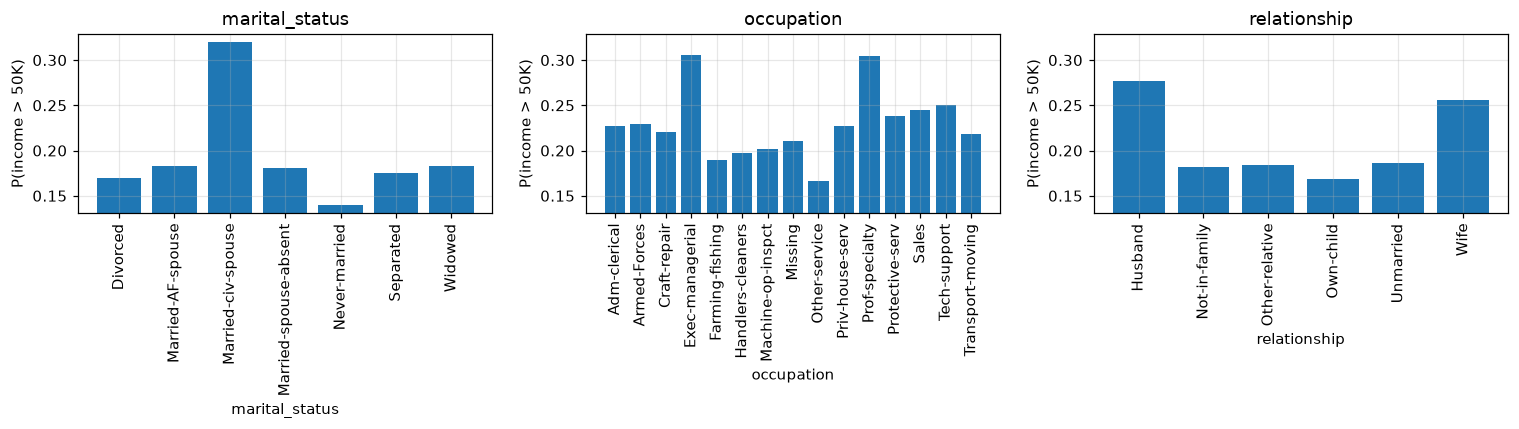

In [19]:
pdp_cat = ["marital_status", "occupation", "relationship"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 3000),
    features=pdp_cat, categorical_features=pdp_cat,
    ax=axes, random_state=RANDOM_STATE)
for a, name in zip(axes, pdp_cat):
    a.set_title(name); a.tick_params(axis="x", rotation=90)
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.2 ICE — un-averaging the PDP

Each thin line is one individual's prediction as we sweep the feature; the thick line is their
average, i.e. the PDP. **Centred ICE** (`centered=True`) subtracts each curve's value at the left
edge, so all lines start at 0 and only the *change* is compared — this is what reveals whether the
population moves together.

*Fanning* lines = the feature's effect depends on other features = **interactions**.

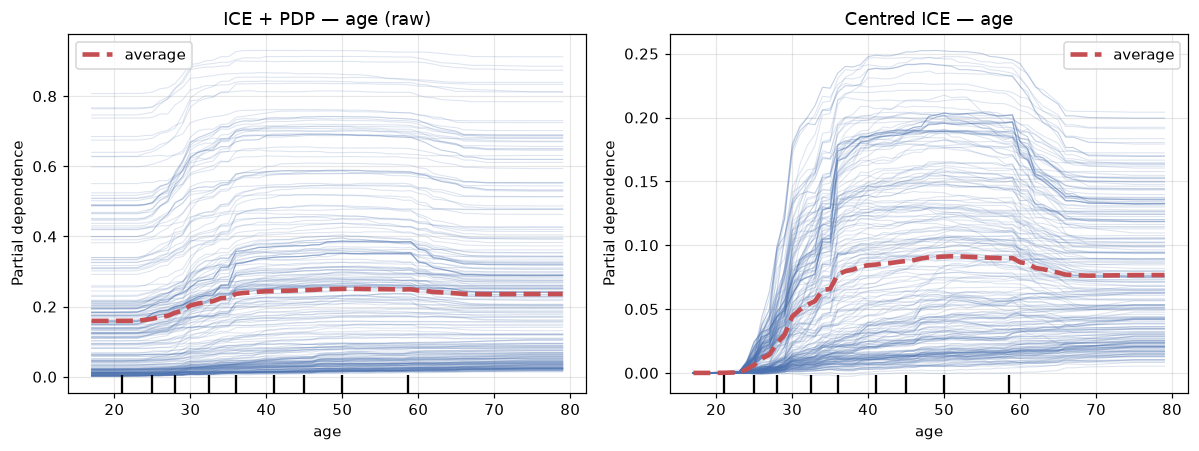

In [20]:
ice_sample = sample_df(X_test, 250)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", ax=axes[0],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[0].set_title("ICE + PDP — age (raw)")

PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", centered=True, ax=axes[1],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[1].set_title("Centred ICE — age")
for a in axes:
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.3 Two-way PDP — visualising an interaction

A 2-D partial dependence surface marginalises over everything *except* two features. If the contours
were parallel horizontal/vertical bands the features would act additively; contours that bend show
the effect of one depends on the level of the other.

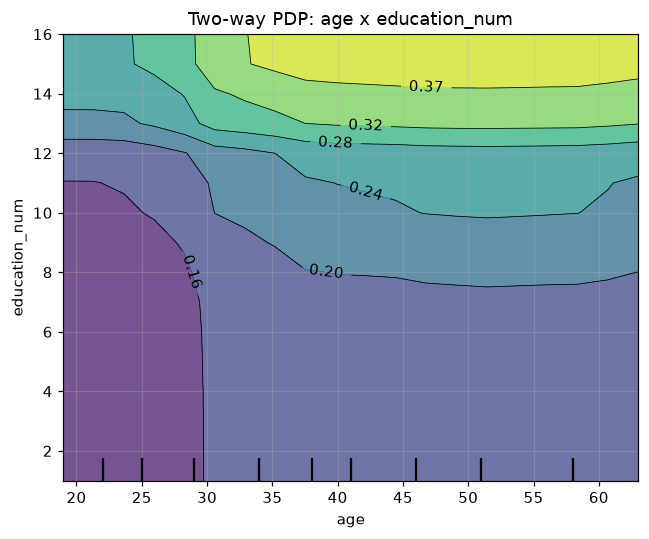

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 2000),
    features=[("age", "education_num")], kind="average",
    grid_resolution=20, ax=ax, random_state=RANDOM_STATE)
ax.set_title("Two-way PDP: age x education_num")
plt.tight_layout(); plt.show()

## 10. Summary and practical guidance

| Method | Scope | Model-agnostic? | Gives direction? | Main weakness |
|---|---|---|---|---|
| **Permutation** | global | yes | no | breaks feature correlation; shared credit |
| **PDP / ICE** | global | yes | **yes** | extrapolates off-manifold; averages hide subgroups |



### References

* Friedman, J. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* — original PDP.
* Goldstein et al. (2015). *Peeking Inside the Black Box* — ICE plots.
* Breiman, L. (2001). *Random Forests* — permutation importance.
* Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions* — SHAP.
* Lundberg et al. (2020). *From local explanations to global understanding with explainable AI for trees* — TreeSHAP.
* Molnar, C. *Interpretable Machine Learning* — https://christophm.github.io/interpretable-ml-book/
* scikit-learn User Guide §4.1 (Partial dependence) and §4.2 (Permutation importance).

# Explainable AI Using PDP, ICE, and PFI

### Dataset

Use the **UCI Wine Quality Dataset** to build a machine learning model for predicting wine quality from its physicochemical properties.

### Objective

In this experiment, apply three Explainable AI (XAI) techniques:

* **Partial Dependence Plot (PDP)** – to understand the average effect of a feature on model predictions.
* **Individual Conditional Expectation (ICE)** – to understand how a feature affects predictions for individual samples.
* **Permutation Feature Importance (PFI)** – to identify the features that have the greatest impact on model performance.

### Task 1: Load and Prepare the Dataset

* Load the Wine Quality dataset.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm.
* Train the model using the training dataset.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

### Task 3: Partial Dependence Plot (PDP)

Generate PDPs for:

* `alcohol`
* `volatile acidity`
* `sulphates`

**Comment:**
Explain how the predicted wine quality changes when each feature varies, while the effects of the other features are averaged out.

### Task 4: Individual Conditional Expectation (ICE)

Generate ICE plots for:

* `alcohol`
* `volatile acidity`
* `sulphates`

Use at least **10 individual wine samples**.

**Comment:**
Explain how the prediction changes for each individual sample as the selected feature changes. Compare the individual curves with the overall PDP trend.

### Task 5: Permutation Feature Importance (PFI)

Calculate PFI for **all input features**.

* Randomly shuffle one feature at a time.
* Measure the decrease in model performance.
* Rank the features according to their PFI scores.
* Display the results using a bar chart.

**Comment:**
Identify which features are most important to the model based on the decrease in performance after permutation.

### Task 6: Compare PDP, ICE, and PFI

Compare the results obtained from all three XAI techniques.

Discuss:

1. Which features are most influential?
2. What is the relationship between the important features and the prediction?
3. Is the relationship linear or nonlinear?
4. Do individual ICE curves follow the average PDP trend?
5. Are there differences between individual samples?
6. Does the PFI ranking agree with the PDP and ICE observations?

### Final Observation

Write a short conclusion explaining how **PDP, ICE, and PFI provide complementary information** about the behavior and importance of features in the trained machine learning model.


Task - 01

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# Load UCI Wine Quality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

# Display first few records
print("First 5 records:")
display(df.head())

# Dataset dimensions
print("Dataset dimensions:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Separate features and target
X = df.drop("quality", axis=1)
y = df["quality"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape)
print("Testing samples:", X_test.shape)

First 5 records:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Dataset dimensions: (1599, 12)

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Training samples: (1279, 11)
Testing samples: (320, 11)


Task - 02

In [23]:
# Create Random Forest regression model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Performance:
MAE  : 0.4251
RMSE : 0.5531
R²   : 0.5319


Task - 03

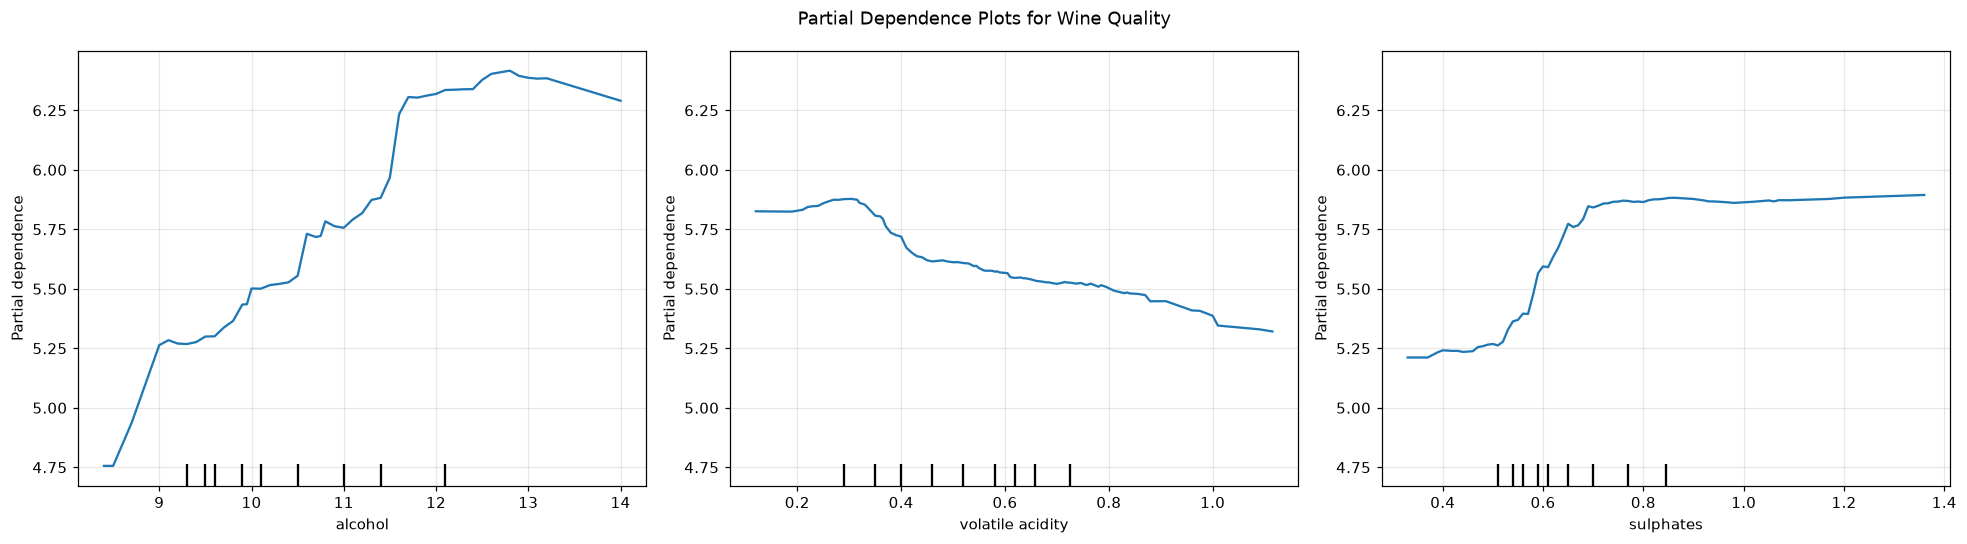

In [24]:
features = ["alcohol", "volatile acidity", "sulphates"]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features,
    ax=ax
)

plt.suptitle("Partial Dependence Plots for Wine Quality")
plt.tight_layout()
plt.show()

Task -04

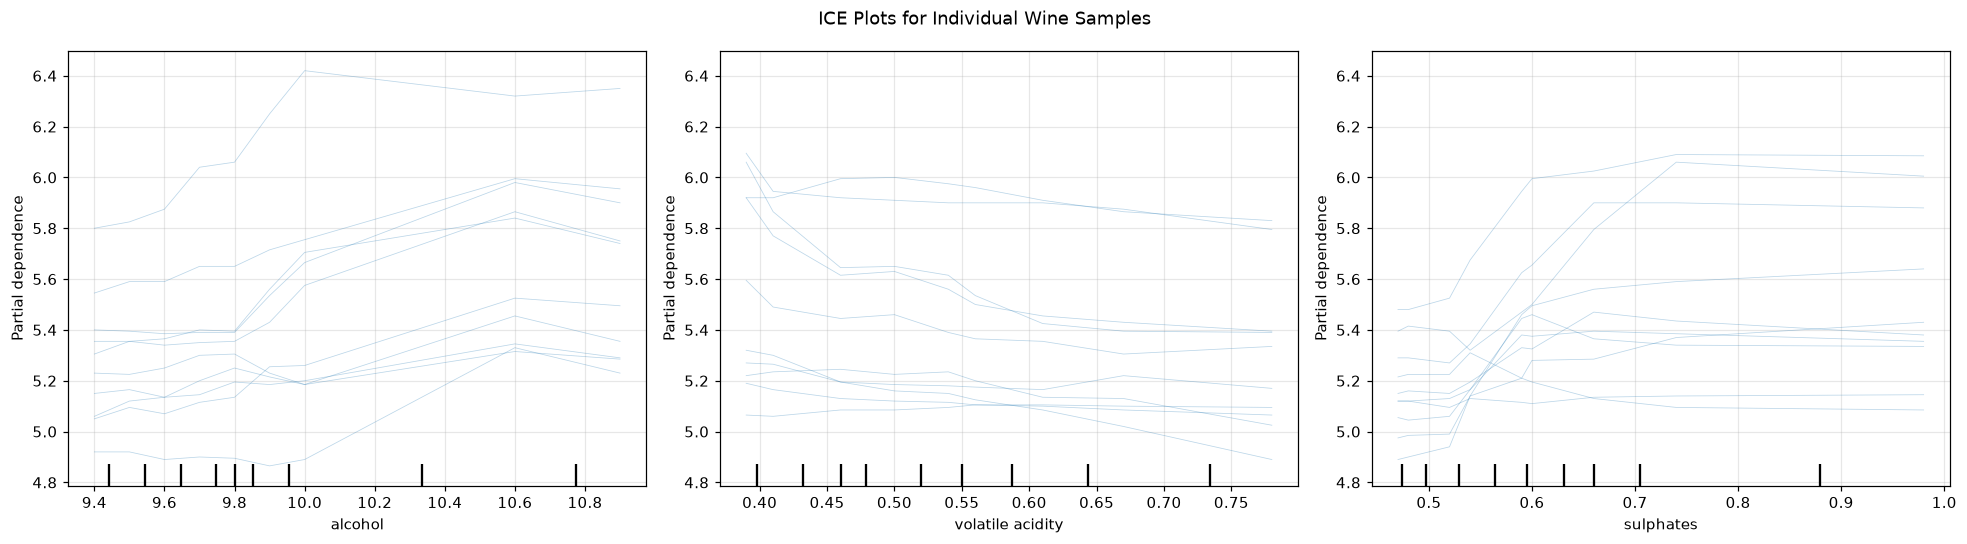

In [25]:
# Select at least 10 individual samples
X_ice = X_test.iloc[:10]

features = ["alcohol", "volatile acidity", "sulphates"]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

PartialDependenceDisplay.from_estimator(
    model,
    X_ice,
    features,
    kind="individual",
    ax=ax
)

plt.suptitle("ICE Plots for Individual Wine Samples")
plt.tight_layout()
plt.show()

task - 05

Permutation Feature Importance:


,Feature,Importance
10,alcohol,0.383628
9,sulphates,0.243227
1,volatile acidity,0.137699
6,total sulfur dioxide,0.071583
8,pH,0.029063
7,density,0.026423
0,fixed acidity,0.025494
5,free sulfur dioxide,0.023415
4,chlorides,0.016484
3,residual sugar,0.013135


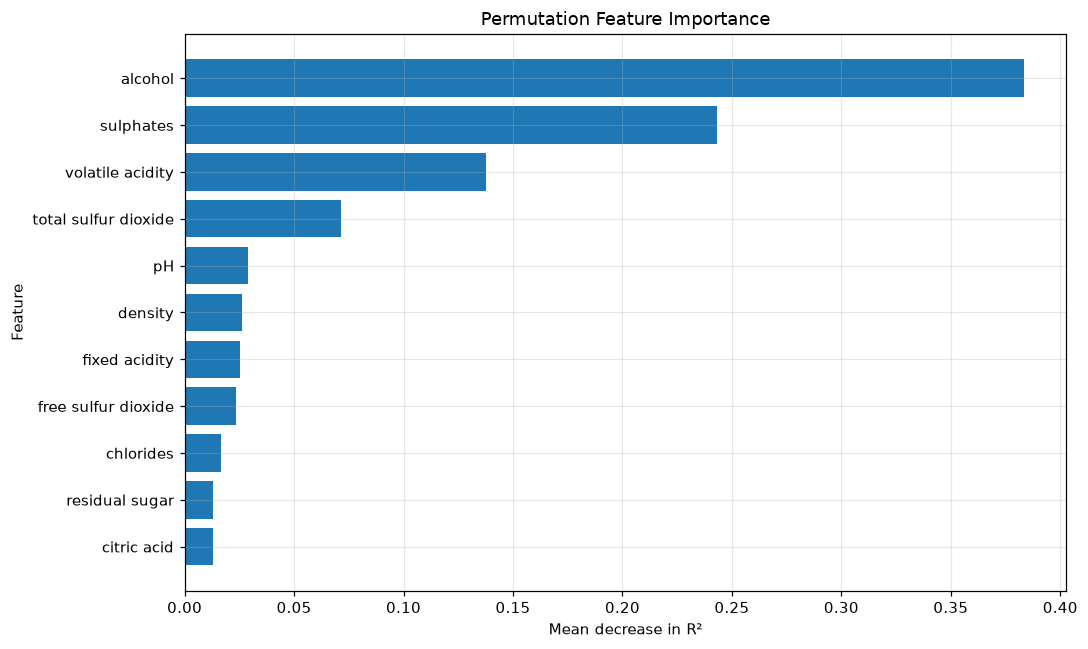

In [26]:
# Calculate permutation feature importance
pfi = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

# Create results dataframe
pfi_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": pfi.importances_mean
})

# Sort by importance
pfi_df = pfi_df.sort_values(
    "Importance",
    ascending=False
)

print("Permutation Feature Importance:")
display(pfi_df)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    pfi_df["Feature"],
    pfi_df["Importance"]
)

plt.xlabel("Mean decrease in R²")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Task - 06

1. Which features are most influential?

According to the Permutation Feature Importance (PFI) results, the three most influential features are:

Rank	Feature	PFI
1	Alcohol	0.383628
2	Sulphates	0.243227
3	Volatile acidity	0.137699

Therefore, alcohol is the most influential feature, followed by sulphates and volatile acidity. The remaining features have considerably lower importance values.

2. What is the relationship between the important features and the prediction?

The PDP plots show the following relationships with predicted wine quality:

Alcohol: Positive relationship. As alcohol increases, predicted wine quality generally increases, with a strong increase around the higher alcohol range.
Sulphates: Positive relationship. Predicted quality increases considerably as sulphates increase, after which the effect becomes almost stable.
Volatile acidity: Negative relationship. As volatile acidity increases, the predicted wine quality generally decreases.

Thus, higher alcohol and sulphates tend to increase predicted quality, whereas higher volatile acidity tends to decrease it.

3. Is the relationship linear or nonlinear?

The relationships are nonlinear.

The PDP curves do not form straight lines. For example, alcohol shows gradual increases followed by a sharp increase and then a plateau. Sulphates also show a strong increase followed by stabilization, while volatile acidity shows a decreasing trend with changes in slope.

Therefore, the model captures nonlinear relationships between the important features and wine quality.

4. Do individual ICE curves follow the average PDP trend?

Yes, generally.

The ICE plots broadly follow the trends observed in the PDP plots:

Alcohol: Most individual curves show an increasing trend.
Volatile acidity: Most curves show a decreasing trend.
Sulphates: Most curves show an increasing trend.

However, the individual curves do not perfectly overlap with the average PDP curve because each sample can respond differently to changes in a feature.

5. Are there differences between individual samples?

Yes. The ICE plots clearly show differences between individual samples.

For example, the effect of alcohol varies considerably across observations. Some samples show a stronger increase in predicted quality, while others show a smaller change. Similar variations can be seen for sulphates and volatile acidity.

This indicates that the effect of a feature can depend on the characteristics of the individual wine sample and may indicate interactions with other features.

6. Does the PFI ranking agree with the PDP and ICE observations?

Yes, the PFI ranking is broadly consistent with the PDP and ICE observations.

PFI ranks:

Alcohol – 0.383628
Sulphates – 0.243227
Volatile acidity – 0.137699

These same three features were selected for the PDP and ICE analysis. The plots show that all three have noticeable effects on predicted wine quality.

In particular, alcohol has the highest PFI and also shows a strong effect in the PDP and substantial variation across ICE curves. Sulphates has the second-highest PFI and shows a clear positive PDP trend, while volatile acidity has the third-highest PFI and shows a clear negative PDP trend.

Therefore, the PFI ranking agrees well with the patterns observed in the PDP and ICE plots.

Observation:
The comparison of PDP, ICE and PFI shows that alcohol, sulphates and volatile acidity are the most influential features in predicting wine quality. Alcohol and sulphates have a positive effect on predicted quality, whereas volatile acidity has a negative effect. The PDP curves indicate nonlinear relationships, while the ICE plots reveal variations in feature effects across individual wine samples. The PFI ranking is consistent with the PDP and ICE observations, demonstrating that the three XAI techniques provide complementary insights into the model's behaviour.